# Load dataset and explore the headers and relations.
Check README.md for more information on the dataset. In this project an environment variable "DATASETS_PATH" is used in order to save the path to portfolio datasets. This datatset consits of 5 files, of which we are going to use 3 at this stage (calendar.csv, sales_train_evaluation.csv, sell_prices.csv).

In [6]:
import os
import pandas as pd

DATASETS_PATH = os.getenv("DATASETS_PATH") 

df_calendar = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/calendar.csv")

print(df_calendar)



            date  wm_yr_wk    weekday  wday  month  year       d  \
0     2011-01-29     11101   Saturday     1      1  2011     d_1   
1     2011-01-30     11101     Sunday     2      1  2011     d_2   
2     2011-01-31     11101     Monday     3      1  2011     d_3   
3     2011-02-01     11101    Tuesday     4      2  2011     d_4   
4     2011-02-02     11101  Wednesday     5      2  2011     d_5   
...          ...       ...        ...   ...    ...   ...     ...   
1964  2016-06-15     11620  Wednesday     5      6  2016  d_1965   
1965  2016-06-16     11620   Thursday     6      6  2016  d_1966   
1966  2016-06-17     11620     Friday     7      6  2016  d_1967   
1967  2016-06-18     11621   Saturday     1      6  2016  d_1968   
1968  2016-06-19     11621     Sunday     2      6  2016  d_1969   

      event_name_1 event_type_1  event_name_2 event_type_2  snap_CA  snap_TX  \
0              NaN          NaN           NaN          NaN        0        0   
1              NaN     

One can see here 14 columns and 1969 rows. The frame implies 1969 days with a calendar date, coding for the week (an integer number), coding for the week day, month number, two possible events and their occurances in three states of the USA. 

In [7]:
df_sell_prices = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/sell_prices.csv")

print(df_sell_prices)

        store_id        item_id  wm_yr_wk  sell_price
0           CA_1  HOBBIES_1_001     11325        9.58
1           CA_1  HOBBIES_1_001     11326        9.58
2           CA_1  HOBBIES_1_001     11327        8.26
3           CA_1  HOBBIES_1_001     11328        8.26
4           CA_1  HOBBIES_1_001     11329        8.26
...          ...            ...       ...         ...
6841116     WI_3    FOODS_3_827     11617        1.00
6841117     WI_3    FOODS_3_827     11618        1.00
6841118     WI_3    FOODS_3_827     11619        1.00
6841119     WI_3    FOODS_3_827     11620        1.00
6841120     WI_3    FOODS_3_827     11621        1.00

[6841121 rows x 4 columns]


One can find here the weekly prices for an item per store

In [8]:
df_sales = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/sales_train_evaluation.csv")

print(df_sales)

                                  id        item_id    dept_id   cat_id  \
0      HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES   
1      HOBBIES_1_002_CA_1_evaluation  HOBBIES_1_002  HOBBIES_1  HOBBIES   
2      HOBBIES_1_003_CA_1_evaluation  HOBBIES_1_003  HOBBIES_1  HOBBIES   
3      HOBBIES_1_004_CA_1_evaluation  HOBBIES_1_004  HOBBIES_1  HOBBIES   
4      HOBBIES_1_005_CA_1_evaluation  HOBBIES_1_005  HOBBIES_1  HOBBIES   
...                              ...            ...        ...      ...   
30485    FOODS_3_823_WI_3_evaluation    FOODS_3_823    FOODS_3    FOODS   
30486    FOODS_3_824_WI_3_evaluation    FOODS_3_824    FOODS_3    FOODS   
30487    FOODS_3_825_WI_3_evaluation    FOODS_3_825    FOODS_3    FOODS   
30488    FOODS_3_826_WI_3_evaluation    FOODS_3_826    FOODS_3    FOODS   
30489    FOODS_3_827_WI_3_evaluation    FOODS_3_827    FOODS_3    FOODS   

      store_id state_id  d_1  d_2  d_3  d_4  ...  d_1932  d_1933  d_1934  \
0         CA_1       CA

This frame represents the actual number of sales per day per store. Let's start our Exploratory Data Analysis (EDA) from this frame.

# How many unique stores, group of itmes and item names are there?

In [10]:
unique_stores = df_sales["store_id"].unique().tolist()
print(unique_stores)

['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']


In [11]:
unique_categories = df_sales["cat_id"].unique().tolist()
print(unique_categories)

['HOBBIES', 'HOUSEHOLD', 'FOODS']


In [12]:
unique_departments = df_sales["dept_id"].unique().tolist()
print(unique_departments)

['HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2', 'FOODS_1', 'FOODS_2', 'FOODS_3']


In [14]:
unique_items = df_sales["item_id"].unique().tolist()
print("Number of unique items: " + str(len(unique_items)))
print(unique_items)

Number of unique items: 3049
['HOBBIES_1_001', 'HOBBIES_1_002', 'HOBBIES_1_003', 'HOBBIES_1_004', 'HOBBIES_1_005', 'HOBBIES_1_006', 'HOBBIES_1_007', 'HOBBIES_1_008', 'HOBBIES_1_009', 'HOBBIES_1_010', 'HOBBIES_1_011', 'HOBBIES_1_012', 'HOBBIES_1_013', 'HOBBIES_1_014', 'HOBBIES_1_015', 'HOBBIES_1_016', 'HOBBIES_1_017', 'HOBBIES_1_018', 'HOBBIES_1_019', 'HOBBIES_1_020', 'HOBBIES_1_021', 'HOBBIES_1_022', 'HOBBIES_1_023', 'HOBBIES_1_024', 'HOBBIES_1_025', 'HOBBIES_1_026', 'HOBBIES_1_027', 'HOBBIES_1_028', 'HOBBIES_1_029', 'HOBBIES_1_030', 'HOBBIES_1_031', 'HOBBIES_1_032', 'HOBBIES_1_033', 'HOBBIES_1_034', 'HOBBIES_1_035', 'HOBBIES_1_036', 'HOBBIES_1_037', 'HOBBIES_1_038', 'HOBBIES_1_039', 'HOBBIES_1_040', 'HOBBIES_1_041', 'HOBBIES_1_042', 'HOBBIES_1_043', 'HOBBIES_1_044', 'HOBBIES_1_045', 'HOBBIES_1_046', 'HOBBIES_1_047', 'HOBBIES_1_048', 'HOBBIES_1_049', 'HOBBIES_1_050', 'HOBBIES_1_051', 'HOBBIES_1_052', 'HOBBIES_1_053', 'HOBBIES_1_054', 'HOBBIES_1_055', 'HOBBIES_1_056', 'HOBBIES_1_057', '

# Explore number of sales as a heat map per day in each store.
We want to make first impressions of the distributions of sales for items. This going to help us deciding for the further strategy of the forecast.

In [16]:
df_CA_1_store = df_sales[df_sales["store_id"] == "CA_1"]
print(df_CA_1_store)

                                 id        item_id    dept_id   cat_id  \
0     HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES   
1     HOBBIES_1_002_CA_1_evaluation  HOBBIES_1_002  HOBBIES_1  HOBBIES   
2     HOBBIES_1_003_CA_1_evaluation  HOBBIES_1_003  HOBBIES_1  HOBBIES   
3     HOBBIES_1_004_CA_1_evaluation  HOBBIES_1_004  HOBBIES_1  HOBBIES   
4     HOBBIES_1_005_CA_1_evaluation  HOBBIES_1_005  HOBBIES_1  HOBBIES   
...                             ...            ...        ...      ...   
3044    FOODS_3_823_CA_1_evaluation    FOODS_3_823    FOODS_3    FOODS   
3045    FOODS_3_824_CA_1_evaluation    FOODS_3_824    FOODS_3    FOODS   
3046    FOODS_3_825_CA_1_evaluation    FOODS_3_825    FOODS_3    FOODS   
3047    FOODS_3_826_CA_1_evaluation    FOODS_3_826    FOODS_3    FOODS   
3048    FOODS_3_827_CA_1_evaluation    FOODS_3_827    FOODS_3    FOODS   

     store_id state_id  d_1  d_2  d_3  d_4  ...  d_1932  d_1933  d_1934  \
0        CA_1       CA    0    0    

In [46]:
import numpy as np
arr_sales_ca1 = df_CA_1_store.filter(regex=r"^d_\d+$").to_numpy()
#arr_sales_ca1[arr_sales_ca1 > 50] = 50 # naively remove the outliers
print(arr_sales_ca1)
print("Max = " + str(np.max(arr_sales_ca1)))
print("Mean = " + str(np.mean(arr_sales_ca1)))
print("Median = " + str(np.median(arr_sales_ca1)))

[[ 0  0  0 ...  3  0  1]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  3  0  1]
 ...
 [ 0  0  0 ...  3  0  1]
 [ 0  0  0 ...  1  2  1]
 [ 0  0  0 ...  2 10  5]]
Max = 648
Mean = 1.3234376048159977
Median = 0.0


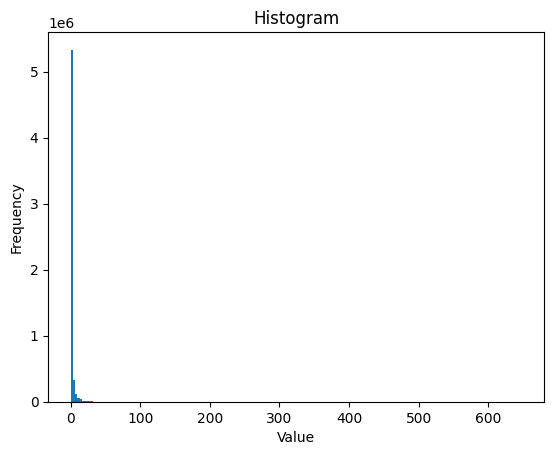

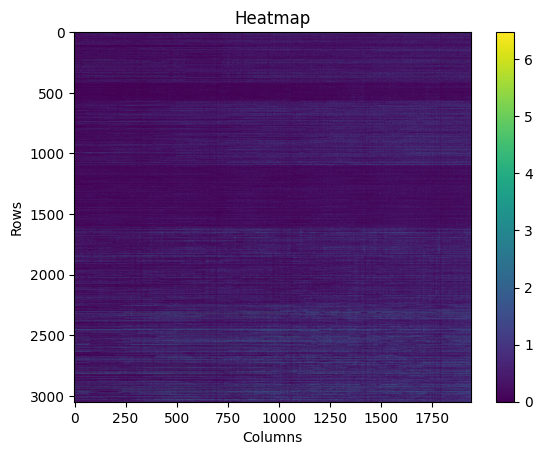

In [81]:
import matplotlib.pyplot as plt

plt.hist(arr_sales_ca1.flatten(), bins=200)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram")
plt.show()

plt.imshow(np.log(arr_sales_ca1 + 1), aspect='auto')
plt.colorbar()
plt.title("Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

# Sum up rows and columns of the heat map.
By doing this we can divide the problem into two 1 dimensional problems.

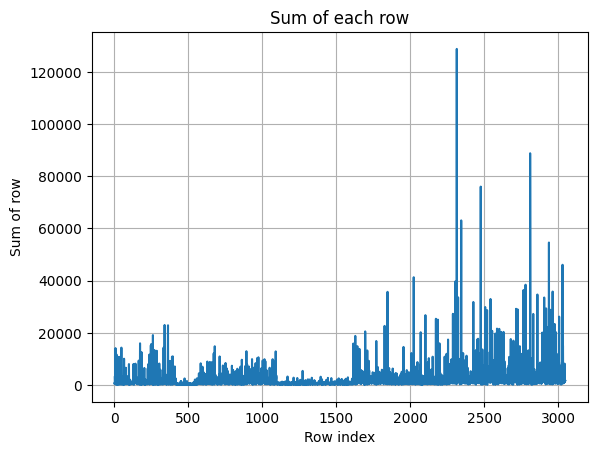

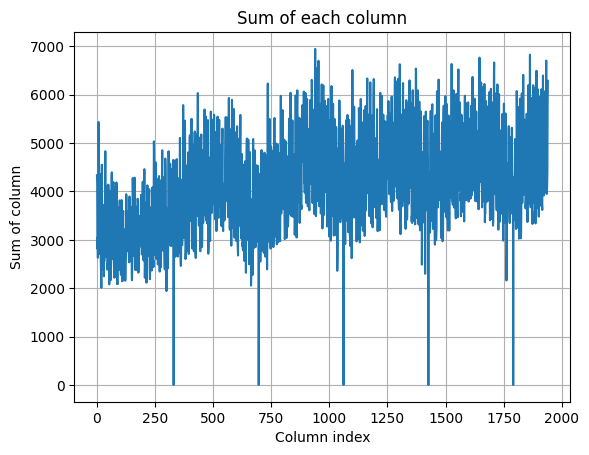

In [48]:
row_sums_ca1 = arr_sales_ca1.sum(axis=1)
column_sums_ca1 = arr_sales_ca1.sum(axis=0)

plt.plot(row_sums_ca1)
plt.xlabel("Row index")
plt.ylabel("Sum of row")
plt.title("Sum of each row")
plt.grid(True)
plt.show()

plt.plot(column_sums_ca1)
plt.xlabel("Column index")
plt.ylabel("Sum of column")
plt.title("Sum of each column")
plt.grid(True)
plt.show()

## Intermidiate conclusions
* There is a very strong seasonality and an obvious trend signals in the temporal dependency of the sum sales for the shop with ID "CA_1". This is very promissing because it could be possible to divide the forecasting into two steps:
    1. Temporal prediction of the cumulative sales (analizing the resulting cumulative sales over time (sum in each column)).
    2. Calculating individual ratio in the sum for each item (analyzing the resulting cumulative sales over items (sum in each row)).
* The first step could be done by fitting an autocorrelation model like ARIMA or SARIMA as the first intuitive approach. But also other models can be tried out.
* The second step could be done by sampling from a simple probabalistic model (like e.g. Dirichlete Multinomial Model, or sorting the items relative to its frequency in the sum of rows and fitting a polynom if the tendency holds for other shops) in order to estimate how much and how likely each item provides to the resulting sum of a column representing a time period.

# Check if the temporal pattern for cumulative sales holds for other shops.
Let's plot the sums of columns also for other shops and see if the pattern matches, or there some bias or different temporal seasonality and trend.

In [69]:
df_CA_2_store = df_sales[df_sales["store_id"] == "CA_2"]
df_CA_3_store = df_sales[df_sales["store_id"] == "CA_3"]
df_CA_4_store = df_sales[df_sales["store_id"] == "CA_4"]

df_TX_1_store = df_sales[df_sales["store_id"] == "TX_1"]
df_TX_2_store = df_sales[df_sales["store_id"] == "TX_2"]
df_TX_3_store = df_sales[df_sales["store_id"] == "TX_3"]

df_WI_1_store = df_sales[df_sales["store_id"] == "WI_1"]
df_WI_2_store = df_sales[df_sales["store_id"] == "WI_2"]
df_WI_3_store = df_sales[df_sales["store_id"] == "WI_3"]

arr_sales_ca2 = df_CA_2_store.filter(regex=r"^d_\d+$").to_numpy()
arr_sales_ca3 = df_CA_3_store.filter(regex=r"^d_\d+$").to_numpy()
arr_sales_ca4 = df_CA_4_store.filter(regex=r"^d_\d+$").to_numpy()

arr_sales_tx1 = df_TX_1_store.filter(regex=r"^d_\d+$").to_numpy()
arr_sales_tx2 = df_TX_2_store.filter(regex=r"^d_\d+$").to_numpy()
arr_sales_tx3 = df_TX_3_store.filter(regex=r"^d_\d+$").to_numpy()

arr_sales_wi1 = df_WI_1_store.filter(regex=r"^d_\d+$").to_numpy()
arr_sales_wi2 = df_WI_2_store.filter(regex=r"^d_\d+$").to_numpy()
arr_sales_wi3 = df_WI_3_store.filter(regex=r"^d_\d+$").to_numpy()

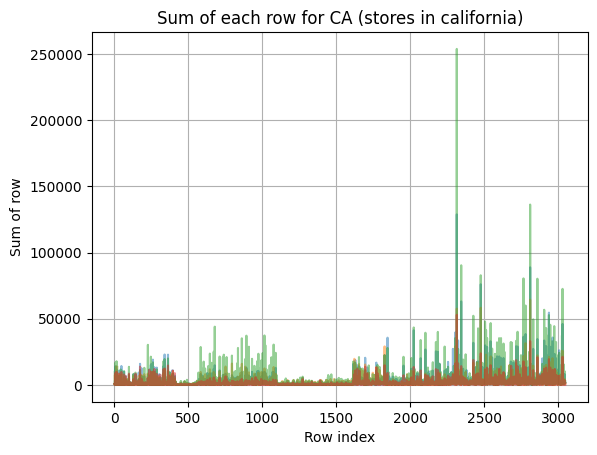

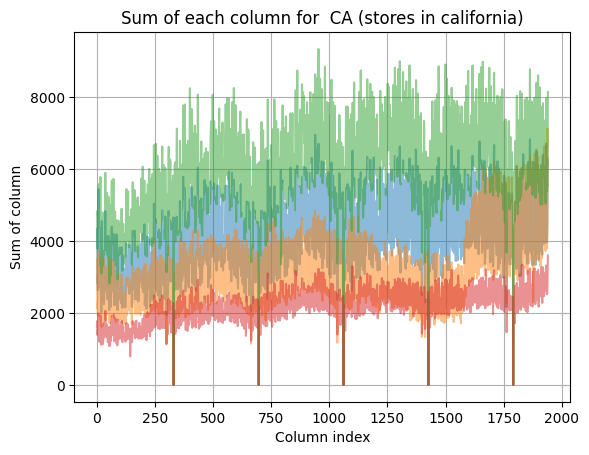

In [70]:
row_sums_ca2 = arr_sales_ca2.sum(axis=1)
column_sums_ca2 = arr_sales_ca2.sum(axis=0)

row_sums_ca3 = arr_sales_ca3.sum(axis=1)
column_sums_ca3 = arr_sales_ca3.sum(axis=0)

row_sums_ca4 = arr_sales_ca4.sum(axis=1)
column_sums_ca4 = arr_sales_ca4.sum(axis=0)

plt.plot(row_sums_ca1, alpha=0.5)
plt.plot(row_sums_ca2, alpha=0.5)
plt.plot(row_sums_ca3, alpha=0.5)
plt.plot(row_sums_ca4, alpha=0.5)
plt.xlabel("Row index")
plt.ylabel("Sum of row")
plt.title("Sum of each row for CA (stores in california)")
plt.grid(True)
plt.show()

plt.plot(column_sums_ca1, alpha=0.5)
plt.plot(column_sums_ca2, alpha=0.5)
plt.plot(column_sums_ca3, alpha=0.5)
plt.plot(column_sums_ca4, alpha=0.5)
plt.xlabel("Column index")
plt.ylabel("Sum of column")
plt.title("Sum of each column for  CA (stores in california)")
plt.grid(True)
plt.show()

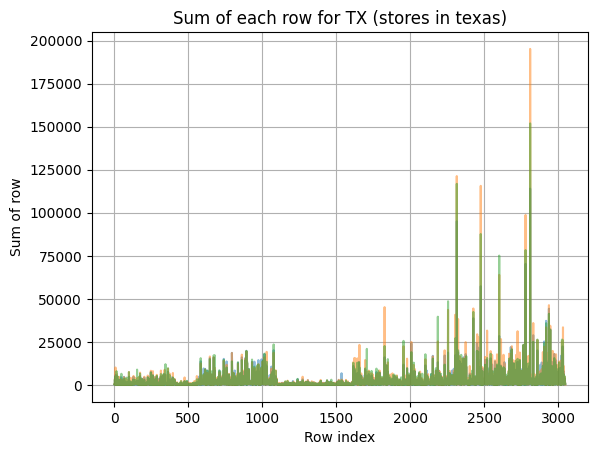

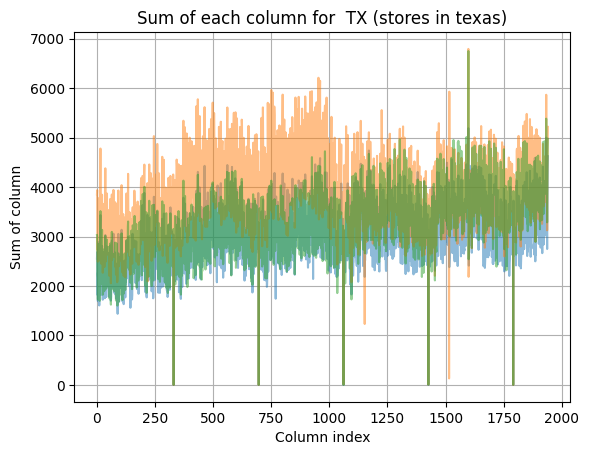

In [71]:
row_sums_tx1 = arr_sales_tx1.sum(axis=1)
column_sums_tx1 = arr_sales_tx1.sum(axis=0)

row_sums_tx2 = arr_sales_tx2.sum(axis=1)
column_sums_tx2 = arr_sales_tx2.sum(axis=0)

row_sums_tx3 = arr_sales_tx3.sum(axis=1)
column_sums_tx3 = arr_sales_tx3.sum(axis=0)

plt.plot(row_sums_tx1, alpha=0.5)
plt.plot(row_sums_tx2, alpha=0.5)
plt.plot(row_sums_tx3, alpha=0.5)
plt.xlabel("Row index")
plt.ylabel("Sum of row")
plt.title("Sum of each row for TX (stores in texas)")
plt.grid(True)
plt.show()

plt.plot(column_sums_tx1, alpha=0.5)
plt.plot(column_sums_tx2, alpha=0.5)
plt.plot(column_sums_tx3, alpha=0.5)
plt.xlabel("Column index")
plt.ylabel("Sum of column")
plt.title("Sum of each column for  TX (stores in texas)")
plt.grid(True)
plt.show()

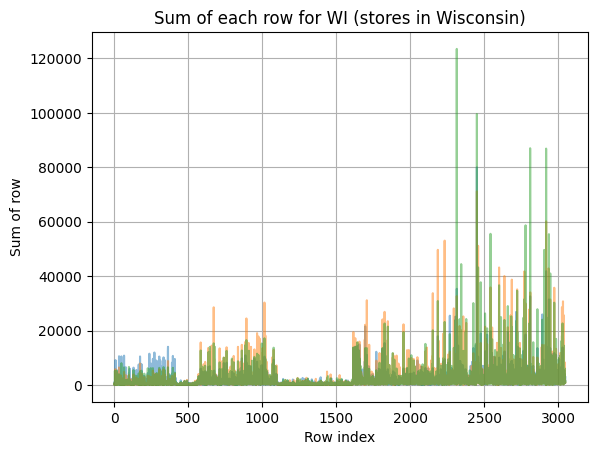

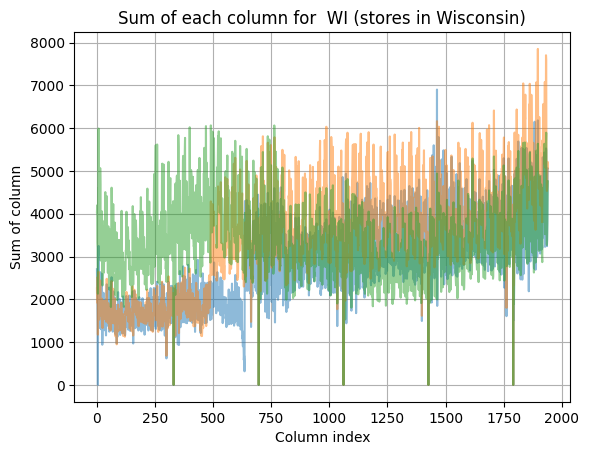

In [72]:
row_sums_wi1 = arr_sales_wi1.sum(axis=1)
column_sums_wi1 = arr_sales_wi1.sum(axis=0)

row_sums_wi2 = arr_sales_wi2.sum(axis=1)
column_sums_wi2 = arr_sales_wi2.sum(axis=0)

row_sums_wi3 = arr_sales_wi3.sum(axis=1)
column_sums_wi3 = arr_sales_wi3.sum(axis=0)

plt.plot(row_sums_wi1, alpha=0.5)
plt.plot(row_sums_wi2, alpha=0.5)
plt.plot(row_sums_wi3, alpha=0.5)
plt.xlabel("Row index")
plt.ylabel("Sum of row")
plt.title("Sum of each row for WI (stores in Wisconsin)")
plt.grid(True)
plt.show()

plt.plot(column_sums_wi1, alpha=0.5)
plt.plot(column_sums_wi2, alpha=0.5)
plt.plot(column_sums_wi3, alpha=0.5)
plt.xlabel("Column index")
plt.ylabel("Sum of column")
plt.title("Sum of each column for  WI (stores in Wisconsin)")
plt.grid(True)
plt.show()

## Intermediate conclusions.
* For all shops independent of the state, there are strong seasonalities and trends in temporal dependency of cumulative sales.
* There are also several and obvious discontinuities, or jumps for one shop in California and two shops in Wisconsin.
* These discontinuities are randomly placed on the time axis.
* They are randomly spread over shops.
* Cause of these jumps should be found by correlation analysis, may be there is strong correlation with price changes, so that demand becomes generaly higher.
* The distribution for items seems very similar for all shops, so let's ensure that it can be modeled by a simple probabalistic model.

# Check the posibility of a simple probabalistic modeling of the cumulative items sales.

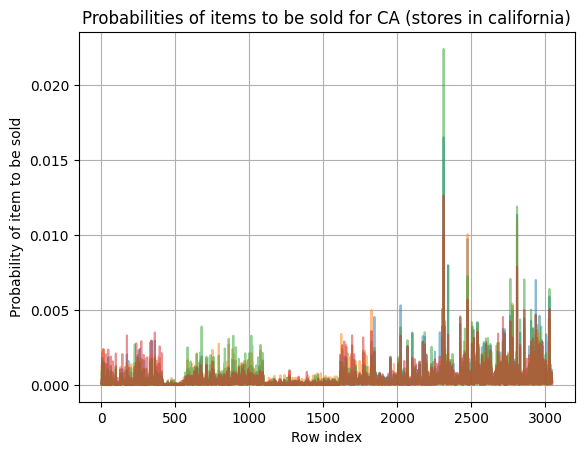

In [73]:
alpha_CA1 = row_sums_ca1
alpha_CA2 = row_sums_ca2
alpha_CA3 = row_sums_ca3
alpha_CA4 = row_sums_ca4

p_CA1 = np.random.dirichlet(alpha_CA1)
p_CA2 = np.random.dirichlet(alpha_CA2)
p_CA3 = np.random.dirichlet(alpha_CA3)
p_CA4 = np.random.dirichlet(alpha_CA4)

plt.plot(p_CA1, alpha=0.5)
plt.plot(p_CA2, alpha=0.5)
plt.plot(p_CA3, alpha=0.5)
plt.plot(p_CA4, alpha=0.5)
plt.xlabel("Row index")
plt.ylabel("Probability of item to be sold")
plt.title("Probabilities of items to be sold for CA (stores in california)")
plt.grid(True)
plt.show()

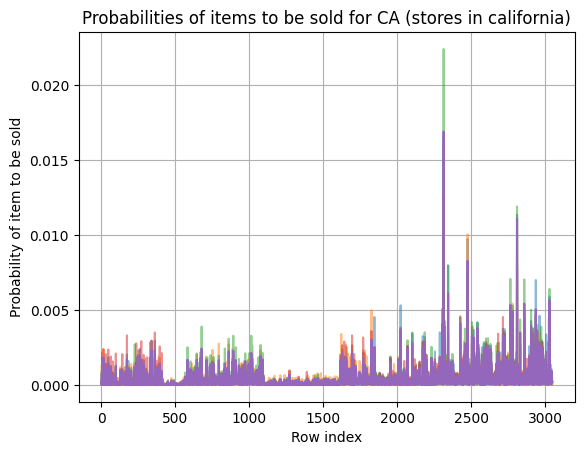

In [76]:
p_CA = np.random.dirichlet(0.25*(alpha_CA1 + alpha_CA2 + alpha_CA3 + alpha_CA4))

plt.plot(p_CA1, alpha=0.5)
plt.plot(p_CA2, alpha=0.5)
plt.plot(p_CA3, alpha=0.5)
plt.plot(p_CA4, alpha=0.5)
plt.plot(p_CA)
plt.xlabel("Row index")
plt.ylabel("Probability of item to be sold")
plt.title("Probabilities of items to be sold for CA (stores in california)")
plt.grid(True)
plt.show()

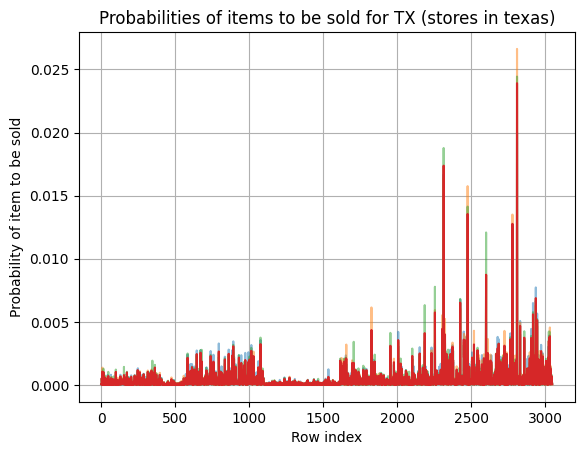

In [80]:
alpha_TX1 = row_sums_tx1
alpha_TX2 = row_sums_tx2
alpha_TX3 = row_sums_tx3

p_TX1 = np.random.dirichlet(alpha_TX1)
p_TX2 = np.random.dirichlet(alpha_TX2)
p_TX3 = np.random.dirichlet(alpha_TX3)

p_TX = np.random.dirichlet(0.333333333*(alpha_TX1 + alpha_TX2 + alpha_TX3))

plt.plot(p_TX1, alpha=0.5)
plt.plot(p_TX2, alpha=0.5)
plt.plot(p_TX3, alpha=0.5)
plt.plot(p_TX)

plt.xlabel("Row index")
plt.ylabel("Probability of item to be sold")
plt.title("Probabilities of items to be sold for TX (stores in texas)")
plt.grid(True)
plt.show()

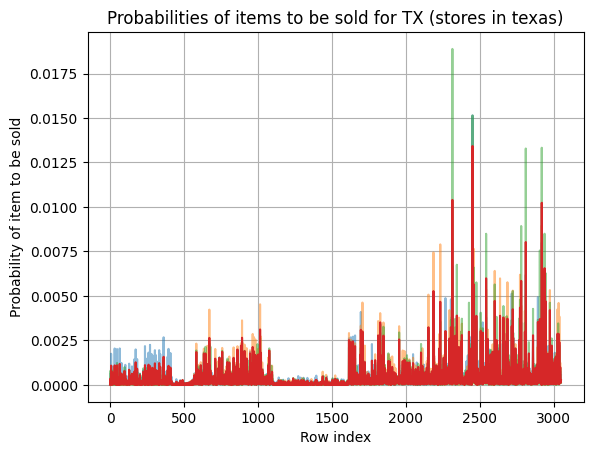

In [82]:
alpha_WI1 = row_sums_wi1
alpha_WI2 = row_sums_wi2
alpha_WI3 = row_sums_wi3

p_WI1 = np.random.dirichlet(alpha_WI1)
p_WI2 = np.random.dirichlet(alpha_WI2)
p_WI3 = np.random.dirichlet(alpha_WI3)

p_WI = np.random.dirichlet(0.333333333*(alpha_WI1 + alpha_WI2 + alpha_WI3))

plt.plot(p_WI1, alpha=0.5)
plt.plot(p_WI2, alpha=0.5)
plt.plot(p_WI3, alpha=0.5)
plt.plot(p_WI)

plt.xlabel("Row index")
plt.ylabel("Probability of item to be sold")
plt.title("Probabilities of items to be sold for WI (stores in Wisconsin)")
plt.grid(True)
plt.show()

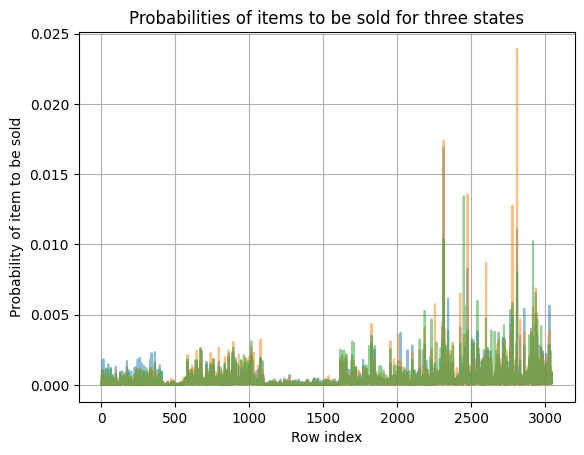

In [83]:
plt.plot(p_CA, alpha=0.5)
plt.plot(p_TX, alpha=0.5)
plt.plot(p_WI, alpha=0.5)

plt.xlabel("Row index")
plt.ylabel("Probability of item to be sold")
plt.title("Probabilities of items to be sold for three states")
plt.grid(True)
plt.show()

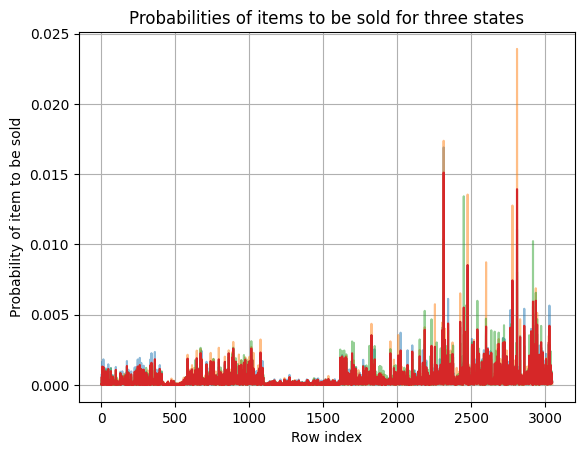

In [84]:
p_Resulting = np.random.dirichlet(0.1*(alpha_WI1 + alpha_WI2 + alpha_WI3 + alpha_TX1 + alpha_TX2 + alpha_TX3 + alpha_CA1 + alpha_CA2 + alpha_CA3 + alpha_CA4))

plt.plot(p_CA, alpha=0.5)
plt.plot(p_TX, alpha=0.5)
plt.plot(p_WI, alpha=0.5)
plt.plot(p_Resulting)

plt.xlabel("Row index")
plt.ylabel("Probability of item to be sold")
plt.title("Probabilities of items to be sold for three states")
plt.grid(True)
plt.show()

In the final experiments, we are going to see if the probability distributions for each state or for average counts perform better, by sampling from a Multinomial distribution. It is possible that there are diffirent meal baskets in different states, so let us leave this question for experimenting.

# Try to find out where the discontinuities in time series of the cumulative sales come from.

The first assumption is, that the jumps in sales are due to price changes (Lower the price higher the demand). By this logic if we plot time series of the prices for each shop there should be jumps in price as well. The question is how to derive a cumulative feature from the prices of each item. Variants are to use cumulative sales and sample from the multinomial with corresponding probability distribution, then sum the prices for cumulative day sales. Another approach is to group the items and derive three values of cumulative prices for each group of items.